# TP2 — Reconstrucción 3D con cámara estéreo

**I308 Visión Artificial · UdeSA · Santiago Luis Groba Alonso - Valentino Nallib Fadel - Joaquin Gustavo Di Cola**

Reconstrucción 3D de un objeto rígido (buda) a partir de pares de imágenes RGB capturados con la cámara estéreo ELP-USB3D1080P02-H120. Las celdas markdown describen, en pasado, lo que hace cada etapa — sirven tanto de guía para escribir el código como de borrador para el informe.

> ## Aclaración: este notebook NO es el entregable principal del TP
>
> El pipeline acá corre end-to-end sobre nuestro **dataset propio** (`datasets/stereo_propio/`, capturado en clase) pero la fusión final **no produce una reconstrucción usable del buda**. La razón es el board AprilTag de Gastón:
>
> - El dict correcto es `DICT_APRILTAG_36H11` (confirmado por Gastón vía mail 2026-05-21), pero la detección es marginal: solo 14/39 capturas tienen markers detectables incluso con upsample 2× y `adaptiveThreshWinSizeMax=31` (los markers están lejos / oblicuos / parcialmente tapados por el buda).
> - Sin el layout `id → celda` del board (Gastón no lo documentó), no podemos hacer pose multi-anchor. Con anchor `ID=17` (el más frecuente) solo 8/39 capturas son usables, todas desde ángulos similares → la nube fusionada queda parcial y fea.
> - **Entregable final del TP**: ver `reconstruccion_3d_catedra.ipynb`, que corre el mismo pipeline sobre el dataset oficial de cátedra (`datasets/stereo_budha_charuco/`) y produce el `.PLY` del buda.
>
> Este notebook queda como **registro del intento + sanity-check del pipeline** sobre el dataset propio. Mantiene valor metodológico: calibración estéreo desde 0, brute-force del dict del board, detección AprilTag con upsampling, intento de fusión.

## 0. Setup

Importamos las librerias del pipeline (`cv2`, `numpy`, `matplotlib`, `open3d`, `tqdm`) y el modulo local `calib.py` (helpers de cátedra: `board_points`, `np_print`, `draw_checkerboard`). Definimos los paths del dataset (`datasets/stereo_propio/`).

In [1]:
import glob
import os
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from tqdm import tqdm

# Helpers de catedra (copiados localmente desde ejemplos clase/)
import calib   # board_points, detect_board, np_print, draw_checkerboard

# --- Dataset propio ---
DATASET_DIR = Path("datasets/stereo_propio")
CALIB_DIR = DATASET_DIR / "calib"
CAPTURES_DIR = DATASET_DIR / "captures"

# --- Chessboard de calibracion ---
# Hoja A4 con tablero 7x10 cuadrados liso, sin markers. Esquinas internas 6x9.
# Square size: 210 mm (ancho A4) / 7 cuadrados = 30 mm.
CHECKERBOARD = (6, 9)        # (cols, rows) de esquinas internas
SQUARE_SIZE_MM = 30.0

# --- Board AprilTag para pose en escena (seccion 4) ---
# Board impreso por Gaston (cat.) con 36 markers AprilTag tag36h11 dispuestos en
# 6x6. Aparece en las capturas del buda y se usa para anclar el frame del
# mundo en cada toma -- NO se usa para calibrar intrinsecos.
BOARD_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_APRILTAG_36H11)
BOARD_MARKER_MM = 64.0   # lado fisico del marker (mm)

print("Setup OK")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Setup OK


## 1. Calibracion estereo

El target de calibracion es un **chessboard liso 7×10 cuadrados** (sin markers ArUco) impreso en A4. Las esquinas internas son **6×9 = 54 puntos por imagen** y cada cuadrado mide 30 mm (210 mm / 7 cuadrados de ancho de A4).

`cv2.findChessboardCorners` (envuelto en `calib.detect_board` con `cornerSubPix`) encuentra las 54 esquinas como una vista coherente por imagen -- sin la ambiguedad planar que tienen los markers individuales. Cada par estereo donde se detecta en AMBAS camaras aporta una vista completa al solver.

**Pipeline**:
1. Detectar el chessboard en cada `left_i.jpg` y `right_i.jpg` (subpix refinement).
2. Acumular las vistas donde se detecta en ambas.
3. Pre-calibrar cada camara con `cv2.calibrateCamera` para obtener intrinsecos iniciales solidos.
4. `cv2.stereoCalibrate` con `CALIB_FIX_INTRINSIC` para estimar solo `R, T` entre camaras.
5. Serializar a `stereo_calibration.pkl`.

> **Nota**: el patron ChArUco chico que aparece en escena (junto al teclado en algunas calib images) NO se usa para calibracion -- es para estimar pose del mundo en cada captura del buda (seccion 4).

In [2]:
# 1.1 Puntos 3D del chessboard en su propio frame
# calib.board_points devuelve un grid (cols * rows, 3) con coordenadas en
# unidades de cuadrado y Z=0. Multiplicamos por SQUARE_SIZE_MM para tener mm.
board_obj_points = (calib.board_points(CHECKERBOARD) * SQUARE_SIZE_MM).astype(np.float32)
print(f"Esquinas internas: {CHECKERBOARD[0]} x {CHECKERBOARD[1]} = {CHECKERBOARD[0]*CHECKERBOARD[1]} puntos / imagen")
print(f"Square size: {SQUARE_SIZE_MM} mm")
print(f"board_obj_points shape: {board_obj_points.shape}")

Esquinas internas: 6 x 9 = 54 puntos / imagen
Square size: 30.0 mm
board_obj_points shape: (1, 54, 3)


In [3]:
# 1.2 Listar pares de imagenes de calibracion (sorted numericamente)
def numeric_sort(file_name):
    return int(os.path.basename(file_name).split("_")[-1].split(".")[0])

left_file_names = sorted(
    glob.glob(str(CALIB_DIR / "*left*.jpg")),
    key=numeric_sort,
)
right_file_names = sorted(
    glob.glob(str(CALIB_DIR / "*right*.jpg")),
    key=numeric_sort,
)
assert len(left_file_names) == len(right_file_names)
print(f"Pares de calibracion en {CALIB_DIR}: {len(left_file_names)}")

Pares de calibracion en datasets\stereo_propio\calib: 163


In [4]:
# 1.3 Loop: detectar chessboard en L y R, paralelizado con ThreadPoolExecutor
# (cv2.findChessboardCorners libera el GIL -> threads dan paralelismo real,
# ~10x con 12 cores). Acumulamos vistas donde se detecta en AMBAS camaras.
from concurrent.futures import ThreadPoolExecutor

def detect_pair(left_fn, right_fn):
    left_image = cv2.imread(left_fn, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_fn, cv2.IMREAD_GRAYSCALE)
    sz = (left_image.shape[1], left_image.shape[0])
    ret_L, corners_L = calib.detect_board(CHECKERBOARD, left_image)
    ret_R, corners_R = calib.detect_board(CHECKERBOARD, right_image)
    return sz, ret_L, corners_L, ret_R, corners_R

with ThreadPoolExecutor(max_workers=12) as ex:
    results = list(tqdm(
        ex.map(detect_pair, left_file_names, right_file_names),
        total=len(left_file_names), desc="Detectando chessboard",
    ))

object_points = []
left_images_points = []
right_images_points = []
image_size = None
for sz, ret_L, corners_L, ret_R, corners_R in results:
    if image_size is None:
        image_size = sz
    if not (ret_L and ret_R):
        continue
    object_points.append(board_obj_points)
    left_images_points.append(corners_L)
    right_images_points.append(corners_R)

n_pairs_ok = len(object_points)
print(f"\nPares con chessboard detectado en L y R: {n_pairs_ok} / {len(left_file_names)}")
print(f"image_size = {image_size}")
assert n_pairs_ok >= 15, "Muy pocas vistas, calibracion va a ser mala"

Detectando chessboard: 100%|██████████| 163/163 [00:01<00:00, 88.19it/s] 


Pares con chessboard detectado en L y R: 161 / 163
image_size = (1920, 1080)


In [5]:
# 1.4 Calibracion estereo desacoplada: primero cada camara por separado, despues
# stereoCalibrate con CALIB_FIX_INTRINSIC.
# Subsampleamos a MAX_VIEWS evenly-spaced: con >40 vistas el LM se vuelve lento
# y el marginal de informacion es chico (la calibracion satura ~30-40 vistas
# bien distribuidas).
MAX_VIEWS = 40
if n_pairs_ok > MAX_VIEWS:
    idx = np.linspace(0, n_pairs_ok - 1, MAX_VIEWS).astype(int)
    obj_sub  = [object_points[i] for i in idx]
    left_sub = [left_images_points[i] for i in idx]
    right_sub = [right_images_points[i] for i in idx]
    print(f"Sub-sampleando {n_pairs_ok} -> {MAX_VIEWS} vistas para acelerar LM")
else:
    obj_sub, left_sub, right_sub = object_points, left_images_points, right_images_points

n_views = len(obj_sub)

print(f"Pre-calibrando camara IZQUIERDA sobre {n_views} vistas...")
err_L, K_L_init, D_L_init, _, _ = cv2.calibrateCamera(
    obj_sub, left_sub, image_size, None, None,
)
print(f"  RMS izq: {err_L:.3f} px")

print(f"Pre-calibrando camara DERECHA...")
err_R, K_R_init, D_R_init, _, _ = cv2.calibrateCamera(
    obj_sub, right_sub, image_size, None, None,
)
print(f"  RMS der: {err_R:.3f} px")

print(f"\nStereoCalibrate con CALIB_FIX_INTRINSIC...")
err, left_K, left_dist, right_K, right_dist, R, T, E, F = cv2.stereoCalibrate(
    obj_sub, left_sub, right_sub,
    K_L_init, D_L_init, K_R_init, D_R_init,
    image_size,
    flags=cv2.CALIB_FIX_INTRINSIC,
)
print(f"RMS re-projection error: {err:.3f} px  (<1 px excelente, <2 px aceptable)")
print(f"baseline ||T||: {np.linalg.norm(T):.2f} mm  (fabricante ELP-USB3D1080P02-H120 ~60 mm)")

Sub-sampleando 161 -> 40 vistas para acelerar LM
Pre-calibrando camara IZQUIERDA sobre 40 vistas...
  RMS izq: 0.465 px
Pre-calibrando camara DERECHA...
  RMS der: 0.488 px

StereoCalibrate con CALIB_FIX_INTRINSIC...
RMS re-projection error: 0.900 px  (<1 px excelente, <2 px aceptable)
baseline ||T||: 63.23 mm  (fabricante ELP-USB3D1080P02-H120 ~60 mm)


In [6]:
# 1.5 Imprimir resultados con np_print (formato lindo de catedra)
to_print = [
    "# Left camera intrinsics:",
    ("left_K",    left_K),
    ("left_dist", left_dist),
    "# Right camera intrinsics:",
    ("right_K",    right_K),
    ("right_dist", right_dist),
    "# Rotation L -> R:",
    ("R", R),
    "# Translation L -> R (mm):",
    ("T", T),
]
for entry in to_print:
    if isinstance(entry, str):
        print(entry)
    else:
        name, arr = entry
        print(f"{name} = {calib.np_print(arr)}\n")

# Left camera intrinsics:
left_K = np.array([
	[   596.463,	     0.000,	   968.980],
	[     0.000,	   595.833,	   543.917],
	[     0.000,	     0.000,	     1.000]
])

left_dist = np.array([
	[  0.003087,	 -0.023971,	  0.000724,	  0.000476,	  0.003822]
])

# Right camera intrinsics:
right_K = np.array([
	[   597.723,	     0.000,	   946.166],
	[     0.000,	   597.525,	   534.544],
	[     0.000,	     0.000,	     1.000]
])

right_dist = np.array([
	[  0.003159,	 -0.024214,	  0.000669,	 -0.000774,	  0.003888]
])

# Rotation L -> R:
R = np.array([
	[     1.000,	    -0.001,	     0.013],
	[     0.001,	     1.000,	    -0.003],
	[    -0.013,	     0.003,	     1.000]
])

# Translation L -> R (mm):
T = np.array([
	[-63.223880],
	[ -0.520947],
	[  0.755717]
])



In [7]:
# 1.6 Serializar la calibracion a pkl (igual que catedra stereo.ipynb cell 21)
calibration_results = {
    'left_K': left_K, 'left_dist': left_dist,
    'right_K': right_K, 'right_dist': right_dist,
    'R': R, 'T': T, 'E': E, 'F': F,
    'image_size': image_size,
    'rms_error': float(err),
    'n_pairs_ok': n_pairs_ok,
}

calibration_file = DATASET_DIR / "stereo_calibration.pkl"
with open(calibration_file, "wb") as f:
    pickle.dump(calibration_results, f)
print(f"Guardado en {calibration_file}")

# Alias para celdas siguientes
K_L, D_L = left_K, left_dist
K_R, D_R = right_K, right_dist
IMAGE_SIZE = image_size
baseline_mm = float(np.linalg.norm(T))

Guardado en datasets\stereo_propio\stereo_calibration.pkl


## 2. Rectificacion estereo

A partir de la calibracion (`K_L`, `D_L`, `K_R`, `D_R`, `R`, `T`), `cv2.stereoRectify` calcula las matrices de proyeccion `P1`, `P2` y la matriz de reproyeccion `Q` (que mapea `(u, v, disparidad)` a `(X, Y, Z)` en el frame de camara rectificada).

`cv2.initUndistortRectifyMap` genera los mapas que `cv2.remap` usa en runtime para aplicar de una sola pasada des-distorsion + rectificacion. Usamos `cv2.CV_32FC1` (mapas en float, como el ejemplo de catedra en stereo.ipynb cell 27).

In [8]:
# 2.1 cv2.stereoRectify (catedra stereo.ipynb cell 25)
# alpha=0 recorta el negro de los bordes (mejor para SGBM); =1 conserva todo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist, right_K, right_dist, image_size, R, T, alpha=0,
)
print(f"P1 =\n{P1}\n")
print(f"P2 =\n{P2}\n")
print(f"Q  =\n{Q}\n")
print(f"validRoi1 = {validRoi1}")
print(f"validRoi2 = {validRoi2}")
print(f"baseline efectivo (-P2[0,3]/P2[0,0]): {-P2[0,3]/P2[0,0]:.2f} mm")

P1 =
[[599.57985517   0.         970.89776611   0.        ]
 [  0.         599.57985517 542.05000305   0.        ]
 [  0.           0.           1.           0.        ]]

P2 =
[[ 5.99579855e+02  0.00000000e+00  9.70897766e+02 -3.79117596e+04]
 [ 0.00000000e+00  5.99579855e+02  5.42050003e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]

Q  =
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -9.70897766e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -5.42050003e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.99579855e+02]
 [ 0.00000000e+00  0.00000000e+00  1.58151418e-02 -0.00000000e+00]]

validRoi1 = (0, 0, 1920, 1080)
validRoi2 = (0, 0, 1920, 1080)
baseline efectivo (-P2[0,3]/P2[0,0]): 63.23 mm


In [9]:
# 2.2 Mapas de des-distorsion + rectificacion (catedra stereo.ipynb cell 27)
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1,
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1,
)
print(f"map shape: {left_map_x.shape}  (igual a image_size {image_size})")
print(f"map dtype: {left_map_x.dtype}")

# Helper para rectificar pares (lo usamos despues en el loop de fusion)
def rectify(left, right):
    left_rect = cv2.remap(left, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_rect = cv2.remap(right, right_map_x, right_map_y, cv2.INTER_LINEAR)
    return left_rect, right_rect

map shape: (1080, 1920)  (igual a image_size (1920, 1080))
map dtype: float32


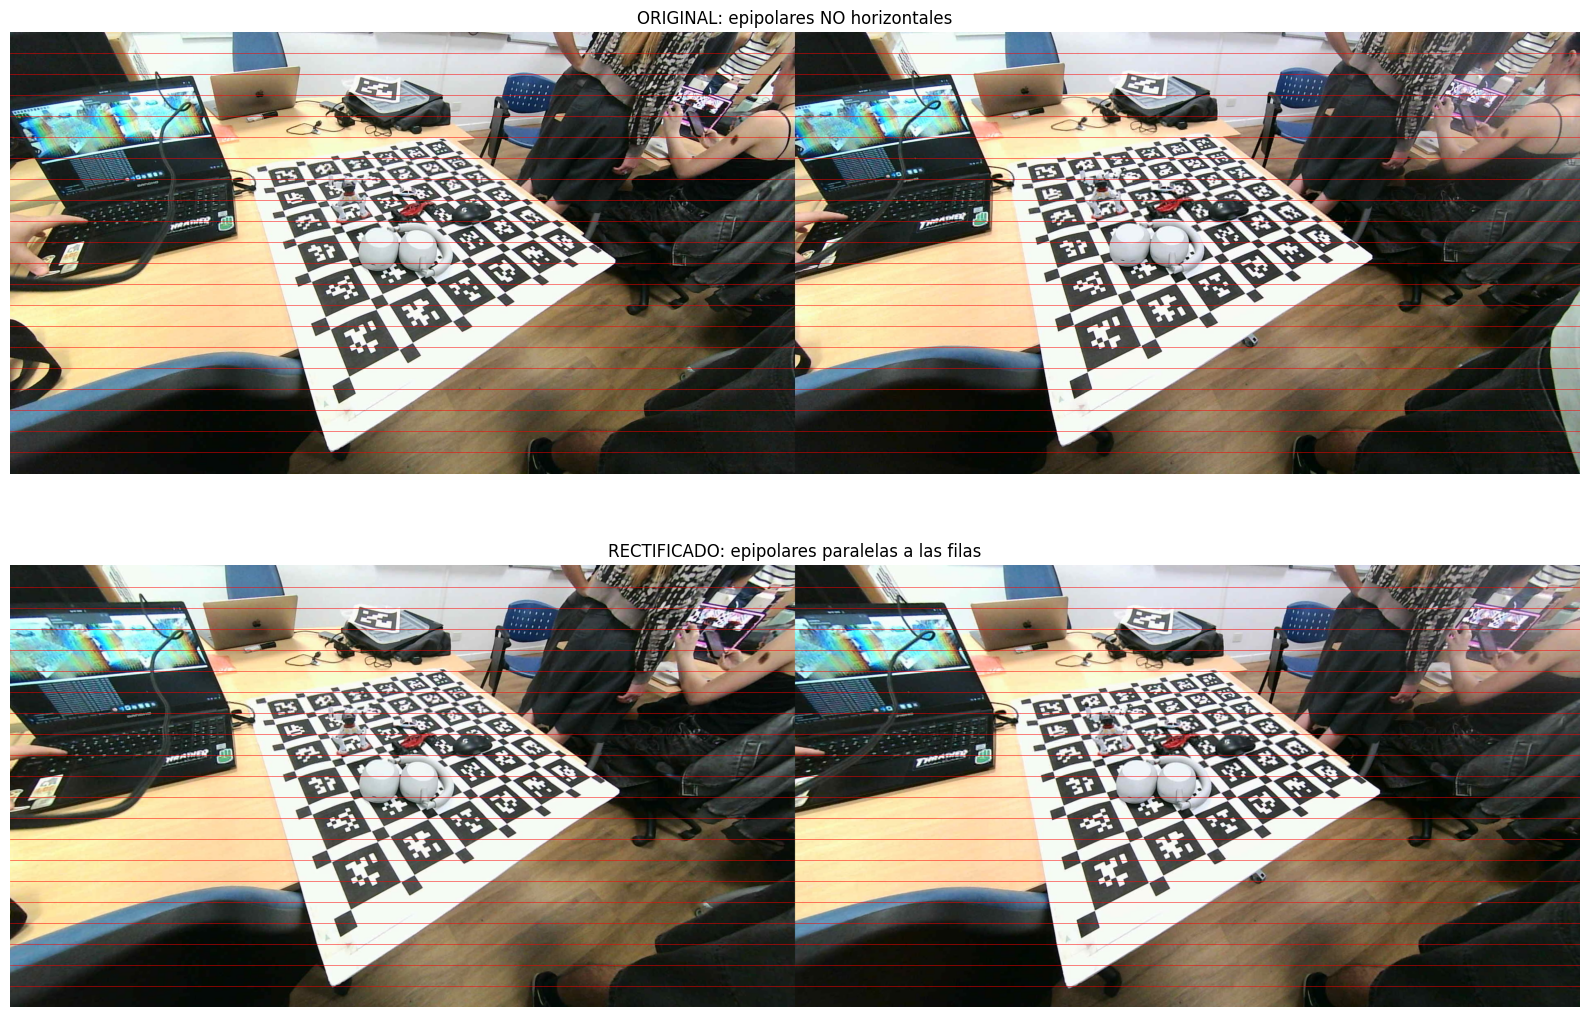

In [10]:
# 2.3 Aplicar a un par de capturas para verificar que las epipolares quedan
# horizontales. Mismo helper que catedra (stereo.ipynb cell 38).
left_raw = cv2.imread(str(CAPTURES_DIR / "left_0.jpg"))
right_raw = cv2.imread(str(CAPTURES_DIR / "right_0.jpg"))
left_rect, right_rect = rectify(left_raw, right_raw)

# Mostrar lado a lado con lineas horizontales para sanity-check de epipolares
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
for ax, (Lp, Rp, t) in zip(axes, [
    (left_raw, right_raw, "ORIGINAL: epipolares NO horizontales"),
    (left_rect, right_rect, "RECTIFICADO: epipolares paralelas a las filas"),
]):
    combined = np.hstack([cv2.cvtColor(Lp, cv2.COLOR_BGR2RGB),
                          cv2.cvtColor(Rp, cv2.COLOR_BGR2RGB)])
    ax.imshow(combined)
    h = combined.shape[0]
    for y in np.linspace(0, h-1, 22)[1:-1]:
        ax.axhline(y=y, color="red", linewidth=0.5, alpha=0.7)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Disparidad

Disparidad = diferencia horizontal entre la posicion de un mismo punto en las imagenes left y right rectificadas. A mas disparidad, mas cerca de la camara: `Z = f * B / d`.

Catedra muestra tres metodos en [stereo.ipynb](ejemplos%20clase/stereo.ipynb):

- **`cv2.StereoBM_create`**: Block Matching clasico. Rapido, ruidoso, sufre con zonas sin textura.
- **`cv2.StereoSGBM_create`**: Semi-Global Block Matching. Mejor cobertura, mas costoso.
- **CREStereo** (deep learning, CVPR 2022): red recurrente con correlacion adaptativa. Disparidad densa con bordes limpios y resistencia a zonas planas. Es el que usa catedra para el output final del pipeline.

Elegimos **CREStereo** via la libreria `disparity` que provee catedra en `ejemplos clase/disparity/`. Corre ONNX -- requiere `onnxruntime`. El modelo se descarga la primera vez a `models/` y queda cacheado.

Salida en pixels (float32); para validez usamos `disparity > 0`.

In [11]:
# 3.1 Disparidad con CREStereo (CRE Stereo, CVPR 2022).
# Setup tomado de catedra (stereo.ipynb): Calibration + InputPair + method.compute_disparity.
# La primera ejecucion descarga el modelo .onnx (~30 MB) a models/; despues queda cacheado.
import sys
sys.path.insert(0, "ejemplos clase")
from disparity.method_cre_stereo import CREStereo
from disparity.methods import Calibration, InputPair, Config

w, h = IMAGE_SIZE
fx, fy = float(K_L[0, 0]), float(K_L[1, 1])
cx0, cy0 = float(K_L[0, 2]), float(K_L[1, 2])

calibration = Calibration(**{
    "width": w, "height": h,
    "baseline_meters": baseline_mm / 1000,
    "fx": fx, "fy": fy,
    "cx0": cx0, "cx1": cx0, "cy": cy0,
    "depth_range": [0.05, 20.0],
    "left_image_rect_normalized": [0, 0, 1, 1],
})

models_path = Path("models"); models_path.mkdir(exist_ok=True)
config = Config(models_path=models_path)

method = CREStereo(config)
method.parameters["Shape"].set_value("1280x720")  # 320x240 / 640x480 / 1280x720
# Defaults: Mode="combined" (2 pasadas), Iterations=10. Mas iters = mejor, mas lento.

def compute_disparity(left_rect, right_rect):
    pair = InputPair(left_rect, right_rect, calibration)
    return method.compute_disparity(pair).disparity_pixels


disparity_map = compute_disparity(left_rect, right_rect)
valid = disparity_map > 0
print(f"disparidad   min={disparity_map[valid].min():.2f}, max={disparity_map[valid].max():.2f}, mean={disparity_map[valid].mean():.2f} px")
print(f"cobertura    {valid.mean()*100:.1f}% de los pixeles validos")

f_px = P1[0, 0]
B_mm = -P2[0, 3] / P2[0, 0]
z_min = f_px * B_mm / disparity_map[valid].max()
z_max = f_px * B_mm / disparity_map[valid].min()
print(f"profundidad  ~{z_min:.0f} mm a ~{z_max:.0f} mm")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(left_rect, cv2.COLOR_BGR2RGB))
axes[0].set_title("Izquierda rectificada"); axes[0].axis("off")
disp_show = np.where(valid, disparity_map, np.nan)
vmin = float(np.nanpercentile(disp_show, 2))
vmax = float(np.nanpercentile(disp_show, 98))
im = axes[1].imshow(disp_show, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Disparidad CREStereo")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.04, label="px")
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'disparity'

## 4. Pose de la cámara respecto al mundo

Para poder fusionar las nubes parciales de los distintos pares en un único frame necesitamos saber, en cada captura, cómo está orientada la cámara izquierda respecto al mundo. Definimos ese mundo anclando el origen a un marker del board AprilTag que aparece en escena.

**Diccionario del board**: `DICT_APRILTAG_36H11` (tag36h11) — 36 markers en grid 6×6 (IDs 0–35), confirmado por Gastón (cátedra). El detector default falla en estas capturas porque los markers están lejos / oblicuos / parcialmente tapados por el buda, así que ajustamos los parámetros (4.1).

**Parámetros de detección clave**:
- **Upsample 2× antes de detectar**: los markers ocupan ~60-100 px en la imagen original; al duplicar la resolución el quad-finder se vuelve mucho más confiable. Las esquinas detectadas se dividen por 2 para volver al frame original.
- `adaptiveThreshWinSizeMax=31`: tamaño de la ventana de threshold adaptativo. El default (23) es chico para markers de este tamaño.
- `errorCorrectionRate=0.0`: sin tolerancia a errores de bits — evita falsos positivos por sub-patches que casualmente decodifican a algún código válido.

Con este setup detectamos en 14/39 capturas (vs 0/39 con default), con 25 IDs únicos y 15 IDs visibles en ≥3 capturas (estables — son markers físicos persistentes).

**Approach de pose**: anclamos el frame del mundo a UN marker individual (`GLOBAL_ANCHOR_ID = 17`, visible en 8/14 capturas con detección). El layout `id → celda` del board no está documentado, así que no podemos hacer fusion multi-anchor sin esa info — fusionamos solo las capturas donde aparece el anchor.

1. Detectar markers en la imagen izquierda **original** (no la rectificada — `K_L`, `D_L` describen el sensor sin rectificar), con upsampling.
2. `cv2.solvePnPGeneric` con `SOLVEPNP_IPPE_SQUARE` sobre las 4 esquinas del anchor y el tamaño conocido (`BOARD_MARKER_MM = 64`). Devuelve 2 soluciones (planar pose ambiguity); elegimos la que tiene +Z marker apuntando hacia la cámara (R[2,2] mínimo).
3. Sanity-check visual: proyectar los ejes X (rojo), Y (verde), Z (azul) con `cv2.drawFrameAxes` y verificar que apuntan donde corresponde.

> **Limitación**: la pose queda relativa al marker anchor, no al centro del board. Para fusión y altura del buda alcanza con que sea consistente entre capturas (el mismo marker físico siempre se decodifica a `ID=17`, ahora que el dict es correcto).

In [ ]:
# 4.1 Brute-force del diccionario sobre TODAS las capturas, con upsample 2x +
# threshold adaptativo agrandado (winSize=31) + ec=0.0 (estricto). El criterio
# de seleccion es "mayor cantidad de IDs estables" (que aparezcan en >=3 capturas),
# no total bruto -- evita los falsos positivos que daban dicts permisivos antes.

candidate_dicts = [
    "DICT_4X4_250", "DICT_4X4_1000",
    "DICT_6X6_250", "DICT_6X6_1000",
    "DICT_ARUCO_MIP_36H12",
    "DICT_APRILTAG_36H10", "DICT_APRILTAG_36H11",
]

# Cargar todas las capturas (gray)
bf_files = sorted(glob.glob(str(CAPTURES_DIR / "left_*.jpg")), key=lambda f: int(Path(f).stem.split("_")[-1]))
bf_imgs_up = [cv2.resize(cv2.imread(f, cv2.IMREAD_GRAYSCALE), None, fx=2.0, fy=2.0,
                          interpolation=cv2.INTER_CUBIC) for f in bf_files]

bf_params = cv2.aruco.DetectorParameters()
bf_params.errorCorrectionRate = 0.0
bf_params.minMarkerPerimeterRate = 0.01
bf_params.adaptiveThreshWinSizeMin = 23
bf_params.adaptiveThreshWinSizeMax = 31
bf_params.adaptiveThreshWinSizeStep = 4

print(f"{'Dict':25s}  total  imgs  unique  estables(>=3)")
print("-" * 70)
bf_results = []
for name in candidate_dicts:
    dic = cv2.aruco.getPredefinedDictionary(getattr(cv2.aruco, name))
    det_bf = cv2.aruco.ArucoDetector(dic, bf_params)
    id_freq = {}
    n_imgs_with = 0
    total = 0
    for img in bf_imgs_up:
        _, ids, _ = det_bf.detectMarkers(img)
        if ids is not None:
            n_imgs_with += 1
            total += len(ids)
            for i in ids.ravel():
                id_freq[int(i)] = id_freq.get(int(i), 0) + 1
    estables = sum(1 for v in id_freq.values() if v >= 3)
    bf_results.append((name, total, n_imgs_with, len(id_freq), estables))
    print(f"{name:25s}  {total:5d}  {n_imgs_with:4d}  {len(id_freq):6d}  {estables:14d}")

winner = max(bf_results, key=lambda r: r[4])
print(f"\nGanador (mas IDs estables >=3 imgs): {winner[0]} ({winner[4]} estables)")
assert winner[0] == "DICT_APRILTAG_36H11", "Cambio el dict ganador, revisar"

Dict                       total  imgs  unique  estables(>=3)
----------------------------------------------------------------------


DICT_4X4_250                  46    30      18               3


DICT_4X4_1000                 99    36      55               8


DICT_6X6_250                   1     1       1               0


DICT_6X6_1000                  1     1       1               0


DICT_ARUCO_MIP_36H12           0     0       0               0


DICT_APRILTAG_36H10            0     0       0               0


DICT_APRILTAG_36H11           83    14      25              15

Ganador (mas IDs estables >=3 imgs): DICT_APRILTAG_36H11 (15 estables)


Test sobre left_2.jpg
Markers detectados: 1  (IDs: [17])
Anchor: ID=17
tvec (mm, frame de camara izq) = [168.4, 160.6, 450.5]
distancia camara-anchor: 507.0 mm

Direccion de cada eje del mundo en frame de camara:
  X(red)  : [-0.85, -0.45, +0.26]  ~ -X(right)
  Y(green): [-0.51, +0.63, -0.59]  ~ +Y(down) 
  Z(blue) : [+0.10, -0.64, -0.77]  ~ -Z(fwd)  


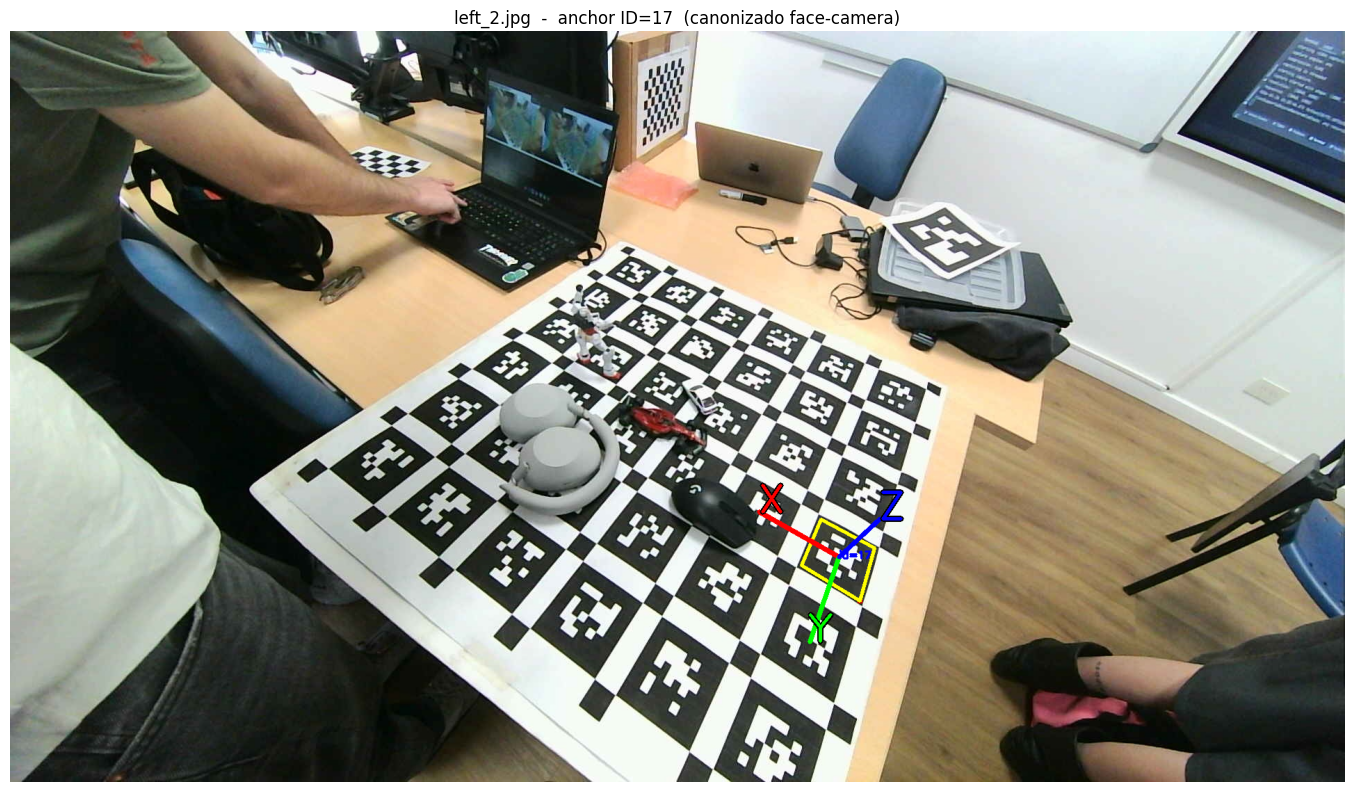

In [ ]:
# 4.2 Pose del mundo, anclada al marker GLOBAL_ANCHOR_ID.
# Detector: AprilTag 36h11 estricto sobre imagen UPSAMPLED 2x (ver 4.1).
# Pose: solvePnPGeneric con IPPE_SQUARE -> 2 soluciones; elegir la que tiene
# +Z marker apuntando a la camara (R[2,2] minimo) -> resuelve planar ambiguity.
# No necesitamos los filtros plane/world-Z que teniamos antes (eran un workaround
# por el dict equivocado que generaba detecciones espurias).

GLOBAL_ANCHOR_ID = 17  # marker mas frecuente entre capturas (8/14 detectables)
UPSAMPLE_FACTOR = 2.0

half = BOARD_MARKER_MM / 2
marker_obj_pts = np.array([
    [-half,  half, 0],   # TL
    [ half,  half, 0],   # TR
    [ half, -half, 0],   # BR
    [-half, -half, 0],   # BL
], dtype=np.float32)

aruco_params = cv2.aruco.DetectorParameters()
aruco_params.errorCorrectionRate = 0.0
aruco_params.minMarkerPerimeterRate = 0.01
aruco_params.adaptiveThreshWinSizeMin = 23
aruco_params.adaptiveThreshWinSizeMax = 31
aruco_params.adaptiveThreshWinSizeStep = 4
aruco_detector = cv2.aruco.ArucoDetector(BOARD_DICT, aruco_params)


def detect_markers_upsampled(image_bgr_or_gray, factor=UPSAMPLE_FACTOR):
    """Detecta markers sobre imagen 2x. Devuelve corners en coordenadas del frame
    ORIGINAL (dividiendo por factor)."""
    gray = (image_bgr_or_gray if image_bgr_or_gray.ndim == 2
            else cv2.cvtColor(image_bgr_or_gray, cv2.COLOR_BGR2GRAY))
    big = cv2.resize(gray, None, fx=factor, fy=factor, interpolation=cv2.INTER_CUBIC)
    corners, ids, rejected = aruco_detector.detectMarkers(big)
    if ids is not None:
        corners = tuple((c / factor).astype(np.float32) for c in corners)
    return corners, ids


def solve_marker_pose_facing_camera(image_pts, K, dist):
    """solvePnPGeneric con IPPE_SQUARE -> elige la solucion con +Z marker
    apuntando hacia la camara (resuelve planar pose ambiguity).
    Devuelve (rvec, tvec, R) o None."""
    n_sols, rvs, tvs, _ = cv2.solvePnPGeneric(
        marker_obj_pts, image_pts, K, dist, flags=cv2.SOLVEPNP_IPPE_SQUARE,
    )
    if n_sols == 0:
        return None
    best_j, best_z = -1, float("inf")
    for j in range(n_sols):
        Rj, _ = cv2.Rodrigues(rvs[j])
        # +Z marker en camara = Rj[:,2]. Componente Z<0 -> marker de frente.
        if Rj[2, 2] < best_z:
            best_z = Rj[2, 2]
            best_j = j
    R, _ = cv2.Rodrigues(rvs[best_j])
    return rvs[best_j], tvs[best_j], R


def estimate_world_pose(left_image_bgr, K, dist,
                        preferred_anchor_id=GLOBAL_ANCHOR_ID,
                        require_preferred=False):
    """Pose del mundo anclada al marker preferido (si esta visible) o al mas
    grande del frame. Devuelve (rvec, tvec, anchor_id, corners, ids) o None."""
    corners, ids = detect_markers_upsampled(left_image_bgr)
    if ids is None or len(ids) == 0:
        return None

    ids_flat = ids.ravel().astype(int)

    if preferred_anchor_id is not None and preferred_anchor_id in ids_flat:
        anchor_local = int(np.where(ids_flat == preferred_anchor_id)[0][0])
    elif require_preferred:
        return None
    else:
        # Mas grande por perimetro = mas confiable
        perims = [float(sum(np.linalg.norm(c[0][(i+1) % 4] - c[0][i]) for i in range(4))) for c in corners]
        anchor_local = int(np.argmax(perims))

    ipts = corners[anchor_local][0].astype(np.float32)
    sol = solve_marker_pose_facing_camera(ipts, K, dist)
    if sol is None:
        return None
    rvec, tvec, _ = sol
    return rvec, tvec, int(ids_flat[anchor_local]), corners, ids


# Test sobre la primera captura donde aparezca el anchor
test_img = None; test_name = None
for f in sorted(glob.glob(str(CAPTURES_DIR / "left_*.jpg")), key=numeric_sort):
    img = cv2.imread(f)
    pose_try = estimate_world_pose(img, K_L, D_L, require_preferred=True)
    if pose_try is not None:
        test_img = img; test_name = Path(f).name
        break
assert test_img is not None, f"Anchor ID={GLOBAL_ANCHOR_ID} no aparece en ninguna captura"

result = estimate_world_pose(test_img, K_L, D_L)
rvec, tvec, anchor_id, all_corners, all_ids = result

print(f"Test sobre {test_name}")
print(f"Markers detectados: {len(all_ids)}  (IDs: {sorted(all_ids.ravel().tolist())})")
print(f"Anchor: ID={anchor_id}")
print(f"tvec (mm, frame de camara izq) = [{tvec[0,0]:.1f}, {tvec[1,0]:.1f}, {tvec[2,0]:.1f}]")
print(f"distancia camara-anchor: {np.linalg.norm(tvec):.1f} mm")

R_dbg, _ = cv2.Rodrigues(rvec)
print("\nDireccion de cada eje del mundo en frame de camara:")
for axis_name, vec in [("X(red)  ", R_dbg[:, 0]), ("Y(green)", R_dbg[:, 1]), ("Z(blue) ", R_dbg[:, 2])]:
    i = int(np.argmax(np.abs(vec)))
    sign = "+" if vec[i] > 0 else "-"
    cam_ax = ["X(right)", "Y(down) ", "Z(fwd)  "][i]
    print(f"  {axis_name}: [{vec[0]:+.2f}, {vec[1]:+.2f}, {vec[2]:+.2f}]  ~ {sign}{cam_ax}")

# Visualizacion
vis = test_img.copy()
cv2.aruco.drawDetectedMarkers(vis, all_corners, all_ids)
anchor_pts = all_corners[int(np.where(all_ids.ravel() == anchor_id)[0][0])][0].astype(int)
cv2.polylines(vis, [anchor_pts], True, (0, 255, 255), 4)

axis_len_mm = BOARD_MARKER_MM * 1.5
cv2.drawFrameAxes(vis, K_L, D_L, rvec, tvec, length=axis_len_mm, thickness=5)

labels_3d = np.float32([[axis_len_mm, 0, 0], [0, axis_len_mm, 0], [0, 0, axis_len_mm]])
labels_2d, _ = cv2.projectPoints(labels_3d, rvec, tvec, K_L, D_L)
for (label, color), pt in zip([("X", (0, 0, 255)), ("Y", (0, 255, 0)), ("Z", (255, 0, 0))],
                               labels_2d.reshape(-1, 2)):
    cv2.putText(vis, label, tuple(pt.astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 8)
    cv2.putText(vis, label, tuple(pt.astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, color, 3)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title(f"{test_name}  -  anchor ID={anchor_id}  (canonizado face-camera)")
ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Reconstrucción 3D de un par

Siguiendo el ejemplo de cátedra ([stereo.ipynb](ejemplos%20clase/stereo.ipynb) — `compute_depth` + back-projection):

1. **Depth**: `Z = f * B / d` para cada pixel con disparidad válida (`compute_depth` helper, igual al de cátedra).
2. **Back-projection**: para cada pixel `(u, v)` con depth `Z`, el punto 3D en el frame de cámara izq RECTIFICADA es `X = (u - cx) * Z / f`, `Y = (v - cy) * Z / f`. Usamos `f, cx, cy` de la matriz rectificada `P1` (no `K_L`) — la disparidad vive en el frame rectificado.
3. **Filtro**: descartamos disparidad `≤ 0` (inválidos) y profundidades fuera de `[100, 2000] mm` (el buda está a ~30-100 cm de la cámara; eso descarta fondo y artefactos).
4. **Llevar al mundo**: tenemos puntos en frame **rectificado**, pero la pose del marker (sección 4.2) está en frame **sin rectificar**. La cadena correcta es:
   ```
   P_world = R_marker^T · (R1^T · P_rect − t_marker)
   ```
   Componemos las dos transformaciones en una matriz 4×4 `T_world_rect` y aplicamos al batch entero.
5. **PointCloud**: `o3d.geometry.PointCloud` con los puntos transformados y los colores del pixel correspondiente en la izquierda rectificada.

Comparado con `cv2.reprojectImageTo3D(disparity, Q)` (que también funcionaría y es lo que algunos tutoriales muestran), `compute_depth` + back-projection manual es lo que hace cátedra y queda más explícito qué pasa con cada componente.

models\crestereo_combined_iter5_720x1280.onnx


Usando par de prueba: left_2.jpg / right_2.jpg


Anchor ID: 17  -  Total puntos: 1,529,180
Markers del board: 1
Slab Z[-50, 300] (sin recorte X/Y): 322,986 puntos
BBOX board X[-300,300] Y[-300,300]: 0 puntos


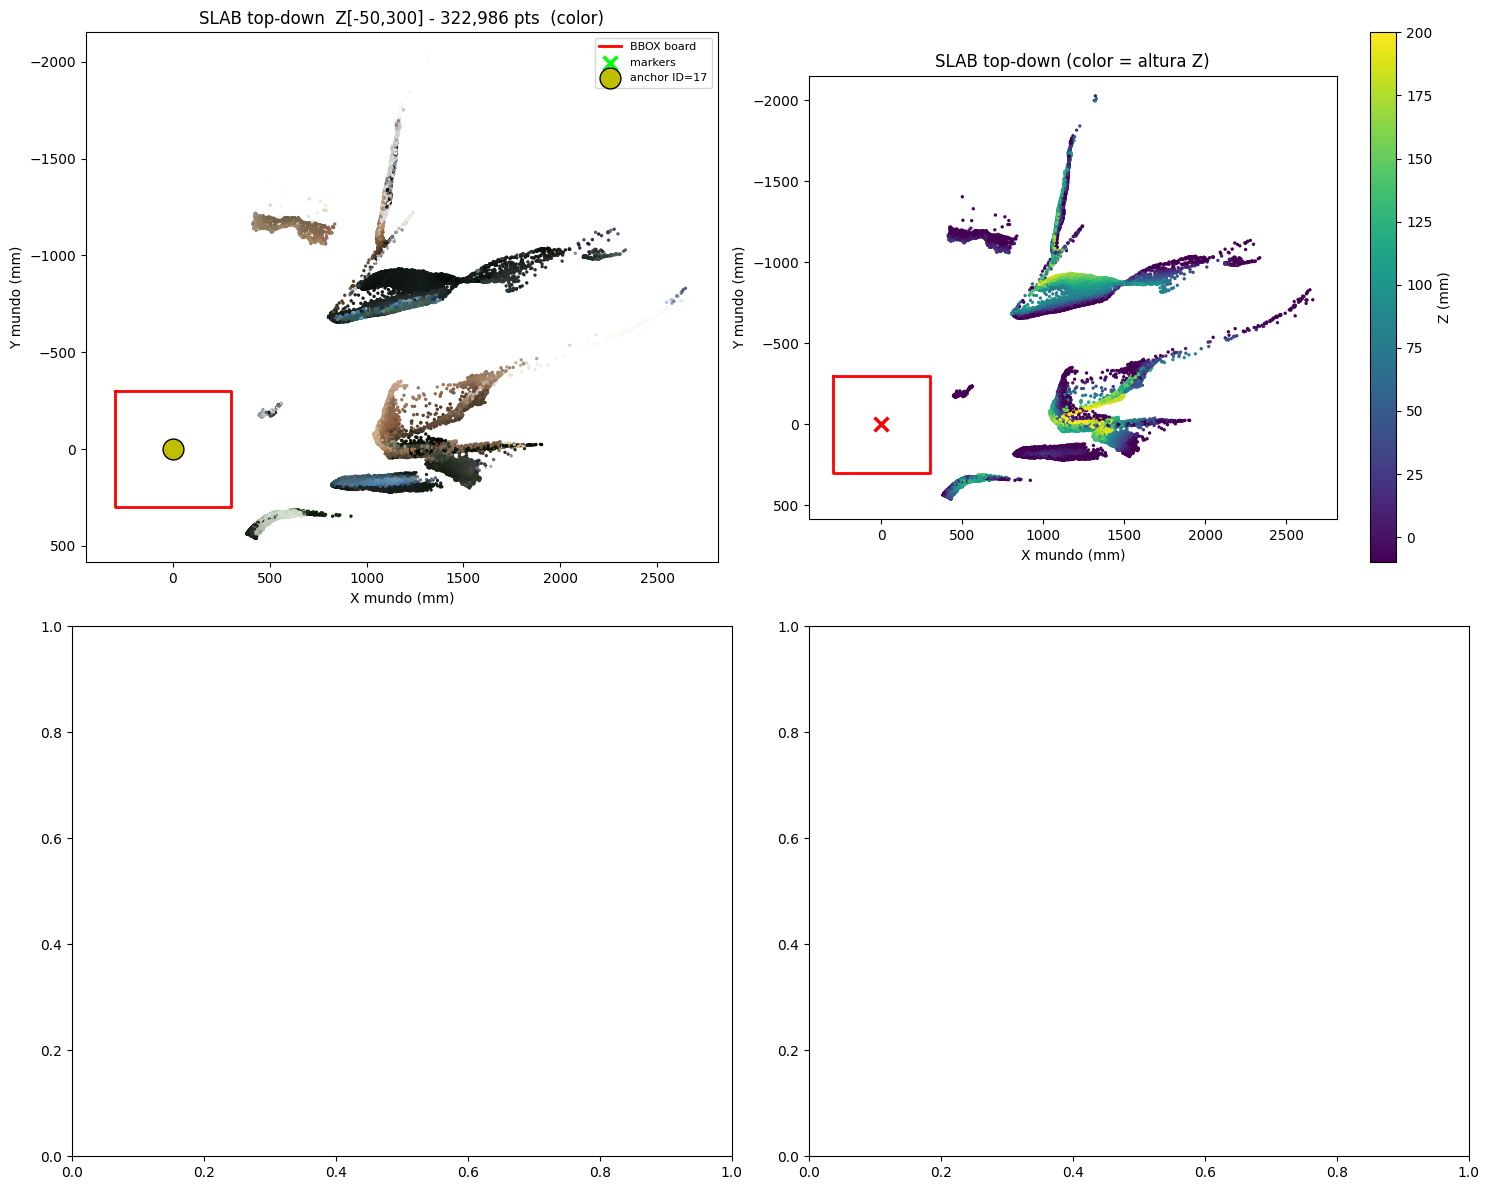

In [ ]:
# 5.1 Reconstruccion 3D de un par de prueba. Sigue catedra (compute_depth +
# back-projection (u-cx)*Z/f), filtra, transforma al frame del mundo y arma una
# o3d.PointCloud lista para fusionar en seccion 6.

def compute_depth(disparity_map, f, B):
    """Z = f * B / disparidad. Disparidad <= 0 -> 0 (se filtra despues)."""
    depth = np.zeros_like(disparity_map, dtype=np.float32)
    valid = disparity_map > 0
    depth[valid] = (f * B) / disparity_map[valid]
    return depth, valid


def pair_to_world_pointcloud(
    left_raw_bgr, left_rect_bgr, disparity_map,
    K_unrect, dist_unrect, P1, R1, P2,
    depth_min_mm=100.0, depth_max_mm=2000.0,
    require_preferred_anchor=True,
):
    """Reconstruccion 3D de un par stereo en el frame del mundo (marker anchor).
    Devuelve (pcd, anchor_id, board_markers_world) o (None, None, None) si fallo."""
    pose = estimate_world_pose(left_raw_bgr, K_unrect, dist_unrect,
                                require_preferred=require_preferred_anchor)
    if pose is None:
        return None, None, None
    rvec, tvec, anchor_id, big_corners, big_ids = pose
    R_marker, _ = cv2.Rodrigues(rvec)

    markers_world = []
    for c in big_corners:
        ipts = c[0].astype(np.float32)
        ok, rv, tv = cv2.solvePnP(marker_obj_pts, ipts, K_unrect, dist_unrect,
                                   flags=cv2.SOLVEPNP_IPPE_SQUARE)
        if ok:
            pos_world = (R_marker.T @ (tv - tvec)).ravel()
            markers_world.append(pos_world)
    markers_world = np.array(markers_world) if markers_world else np.zeros((0, 3))

    f_px = float(P1[0, 0])
    B_mm = float(-P2[0, 3] / P2[0, 0])
    cx = float(P1[0, 2]); cy = float(P1[1, 2])
    depth, valid_disp = compute_depth(disparity_map, f_px, B_mm)

    H, W = depth.shape
    v_grid, u_grid = np.mgrid[0:H, 0:W].astype(np.float32)
    X = (u_grid - cx) * depth / f_px
    Y = (v_grid - cy) * depth / f_px
    Z = depth
    points_rect = np.stack([X, Y, Z], axis=-1)

    mask = valid_disp & (Z >= depth_min_mm) & (Z <= depth_max_mm)
    pts_rect = points_rect[mask].astype(np.float32)
    colors = cv2.cvtColor(left_rect_bgr, cv2.COLOR_BGR2RGB)[mask] / 255.0

    T_unrect_rect = np.eye(4); T_unrect_rect[:3, :3] = R1.T
    T_world_unrect = np.eye(4)
    T_world_unrect[:3, :3] = R_marker.T
    T_world_unrect[:3, 3] = (-R_marker.T @ tvec).ravel()
    T_world_rect = T_world_unrect @ T_unrect_rect

    pts_h = np.hstack([pts_rect, np.ones((len(pts_rect), 1), dtype=np.float32)])
    pts_world = (pts_h @ T_world_rect.T)[:, :3]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_world)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd, anchor_id, markers_world


# --- Aplicacion: primer par donde aparezca el anchor ID=17 ---
test_idx = None
for f in sorted(glob.glob(str(CAPTURES_DIR / "left_*.jpg")), key=numeric_sort):
    img = cv2.imread(f)
    if estimate_world_pose(img, K_L, D_L, require_preferred=True) is not None:
        test_idx = numeric_sort(f); break
assert test_idx is not None, f"Anchor ID={GLOBAL_ANCHOR_ID} no aparece en ninguna captura"

left_raw_test = cv2.imread(str(CAPTURES_DIR / f"left_{test_idx}.jpg"))
right_raw_test = cv2.imread(str(CAPTURES_DIR / f"right_{test_idx}.jpg"))
ltest_rect, rtest_rect = rectify(left_raw_test, right_raw_test)
disp_test = compute_disparity(ltest_rect, rtest_rect)
print(f"Usando par de prueba: left_{test_idx}.jpg / right_{test_idx}.jpg")

pcd, anchor_id, mw = pair_to_world_pointcloud(
    left_raw_test, ltest_rect, disp_test, K_L, D_L, P1, R1, P2,
)
assert pcd is not None

pts_all = np.asarray(pcd.points)
col_all = np.asarray(pcd.colors)
print(f"Anchor ID: {anchor_id}  -  Total puntos: {len(pts_all):,}")
print(f"Markers del board: {len(mw)}")

# Slab horizontal AMPLIO (sin bbox X/Y) -- todo lo que esta cerca del plano
# del board (incluye mesa, board, objetos encima). Util para ver donde cae
# realmente el cloud reconstruido.
SLAB_Z_MIN, SLAB_Z_MAX = -50.0, 300.0
slab_mask = (pts_all[:, 2] >= SLAB_Z_MIN) & (pts_all[:, 2] <= SLAB_Z_MAX)
pts_slab = pts_all[slab_mask]
col_slab = col_all[slab_mask]
print(f"Slab Z[{SLAB_Z_MIN:.0f}, {SLAB_Z_MAX:.0f}] (sin recorte X/Y): {len(pts_slab):,} puntos")

# BBOX estrecho centrado en el anchor + margen (no usamos bbox de markers
# porque pueden ser pocos)
MARGIN = 300
xmin, xmax = -MARGIN, MARGIN
ymin, ymax = -MARGIN, MARGIN
if len(mw) > 0:
    on_board = np.abs(mw[:, 2]) < 80
    if on_board.any():
        mw_board = mw[on_board]
        xmin = min(xmin, float(mw_board[:, 0].min()) - 80)
        xmax = max(xmax, float(mw_board[:, 0].max()) + 80)
        ymin = min(ymin, float(mw_board[:, 1].min()) - 80)
        ymax = max(ymax, float(mw_board[:, 1].max()) + 80)
    else:
        mw_board = np.zeros((0, 3))
else:
    mw_board = np.zeros((0, 3))

BOARD_BBOX = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([xmin, ymin,  -30.0]),
    max_bound=np.array([xmax, ymax,  300.0]),
)
pcd_board = pcd.crop(BOARD_BBOX)
pts_b = np.asarray(pcd_board.points)
col_b = np.asarray(pcd_board.colors)
print(f"BBOX board X[{xmin:.0f},{xmax:.0f}] Y[{ymin:.0f},{ymax:.0f}]: {len(pts_b):,} puntos")

def sub(p, c, n=40000):
    if len(p) <= n: return p, c
    i = np.random.default_rng(0).choice(len(p), n, replace=False)
    return p[i], c[i]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ps, cs = sub(pts_slab, col_slab)
axes[0, 0].scatter(ps[:, 0], ps[:, 1], c=cs, s=2)
axes[0, 0].set_aspect("equal"); axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel("X mundo (mm)"); axes[0, 0].set_ylabel("Y mundo (mm)")
axes[0, 0].set_title(f"SLAB top-down  Z[{SLAB_Z_MIN:.0f},{SLAB_Z_MAX:.0f}] - {len(pts_slab):,} pts  (color)")
axes[0, 0].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin],
                "r-", lw=2, label="BBOX board")
if len(mw_board) > 0:
    axes[0, 0].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="lime", s=100, linewidth=2.5, label="markers")
axes[0, 0].plot(0, 0, "yo", markersize=15, markeredgecolor="black", label=f"anchor ID={anchor_id}")
axes[0, 0].legend(loc="upper right", fontsize=8)

sc = axes[0, 1].scatter(ps[:, 0], ps[:, 1], c=ps[:, 2], s=2, cmap="viridis", vmin=-10, vmax=200)
axes[0, 1].set_aspect("equal"); axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel("X mundo (mm)"); axes[0, 1].set_ylabel("Y mundo (mm)")
axes[0, 1].set_title("SLAB top-down (color = altura Z)")
plt.colorbar(sc, ax=axes[0, 1], label="Z (mm)")
axes[0, 1].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], "r-", lw=2)
if len(mw_board) > 0:
    axes[0, 1].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="red", s=100, linewidth=2.5)

if len(pts_b) > 0:
    pb, cb = sub(pts_b, col_b)
    axes[1, 0].scatter(pb[:, 0], pb[:, 1], c=cb, s=6)
    axes[1, 0].set_aspect("equal"); axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlim(xmin - 50, xmax + 50); axes[1, 0].set_ylim(ymax + 50, ymin - 50)
    axes[1, 0].set_xlabel("X mundo (mm)"); axes[1, 0].set_ylabel("Y mundo (mm)")
    axes[1, 0].set_title(f"ZOOM al BBOX del board - {len(pts_b):,} pts")
    if len(mw_board) > 0:
        axes[1, 0].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="red", s=150, linewidth=3)
    axes[1, 0].plot(0, 0, "yo", markersize=15, markeredgecolor="black")

    axes[1, 1].scatter(pb[:, 0], pb[:, 2], c=cb, s=6)
    axes[1, 1].set_xlabel("X mundo (mm)"); axes[1, 1].set_ylabel("Z mundo (mm)")
    axes[1, 1].set_title("ZOOM bbox del board: vista de costado")
    axes[1, 1].axhline(0, color="red", ls="--", lw=1.5, label="board (Z=0)")
    axes[1, 1].legend()

plt.tight_layout(); plt.show()

## 6. Loop sobre todos los pares + acumulación

Iteramos sobre los pares `(left_i, right_i)` de `captures/`, repitiendo para cada par: rectificar → disparidad → pose del mundo → reconstrucción 3D → recorte → acumular.

**Anchor global**: usamos siempre `ID=17` (visible en 8/14 capturas donde el detector encuentra algo, ≈ 21% del total). Los pares donde no aparece se saltean — perder capturas es preferible a tener el frame del mundo inconsistente entre nubes parciales. Con el dict equivocado (anteriormente) este filtro permitía cualquier captura porque "ID=8" decodificaba en casi todas, pero esos eran matches espurios y por eso la fusión salía como caos.

**Filtros sobre cada nube parcial**:
1. `AxisAlignedBoundingBox` en coordenadas de mundo (X, Y ∈ ±500 mm, Z ∈ [-10, +300] mm). Descarta el piso, la silla, la mesa alrededor y todo lo que no esté en el board + objetos arriba.
2. Acumular sumando con `+=`.

**Post-proceso al final del loop**:
1. `remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)` — saca puntos espurios del matching.
2. `voxel_down_sample(voxel_size=1mm)` — mantiene densidad manejable.

Llevamos cuenta de los pares saltados (sin ID=17 visible o con disparidad fallida) y los reportamos.

Pares de captura: 39



Fusionando capturas:   0%|          | 0/39 [00:00<?, ?it/s]

models\crestereo_combined_iter5_720x1280.onnx



Fusionando capturas:   3%|▎         | 1/39 [00:09<06:07,  9.66s/it]

models\crestereo_combined_iter5_720x1280.onnx


...


Fusionando capturas:  97%|█████████▋| 38/39 [06:06<00:09,  9.32s/it]

models\crestereo_combined_iter5_720x1280.onnx



Fusionando capturas: 100%|██████████| 39/39 [06:17<00:00,  9.74s/it]


Fusionando capturas: 100%|██████████| 39/39 [06:17<00:00,  9.68s/it]


Procesados OK: 8/39
Saltados: 31
  left_0: no ID=17 visible
  left_1: no ID=17 visible
  left_3: no ID=17 visible
  left_4: no ID=17 visible
  left_5: no ID=17 visible
  left_6: no ID=17 visible
  left_7: no ID=17 visible
  left_8: no ID=17 visible
  left_9: no ID=17 visible
  left_10: no ID=17 visible
  left_11: no ID=17 visible
  left_12: no ID=17 visible
  left_13: no ID=17 visible
  left_14: no ID=17 visible
  left_15: no ID=17 visible
  left_17: no ID=17 visible
  left_18: no ID=17 visible
  left_19: no ID=17 visible
  left_25: no ID=17 visible
  left_26: no ID=17 visible
  left_27: no ID=17 visible
  left_28: no ID=17 visible
  left_29: no ID=17 visible
  left_30: no ID=17 visible
  left_31: no ID=17 visible
  left_32: no ID=17 visible
  left_33: no ID=17 visible
  left_34: no ID=17 visible
  left_35: no ID=17 visible
  left_36: no ID=17 visible
  left_37: no ID=17 visible
Total puntos antes de cleanup: 539,677

remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)...
  -> 

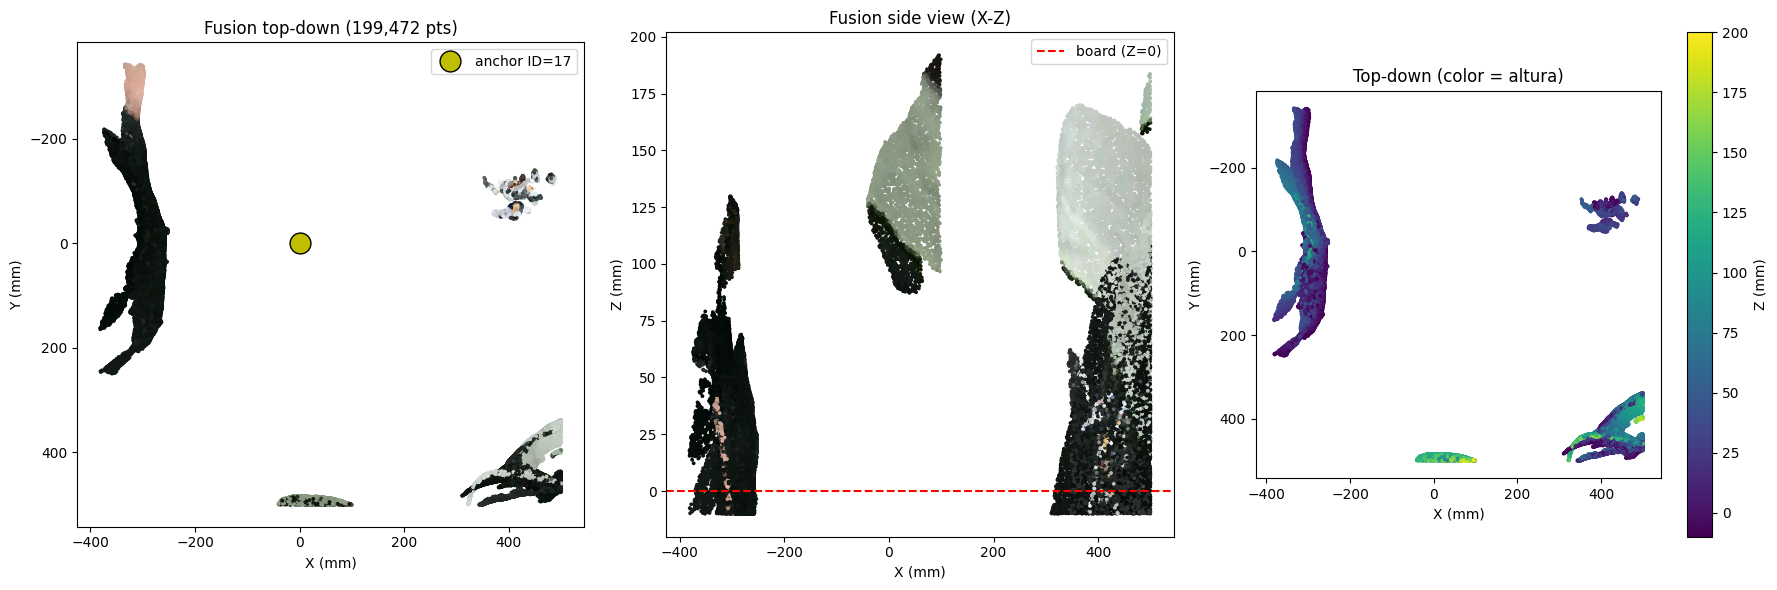

In [ ]:
# 6.1 Loop sobre todos los pares -> fusion en world frame con anchor global GLOBAL_ANCHOR_ID

# Listar pares de captura
left_capture_files = sorted(glob.glob(str(CAPTURES_DIR / "left_*.jpg")), key=numeric_sort)
right_capture_files = sorted(glob.glob(str(CAPTURES_DIR / "right_*.jpg")), key=numeric_sort)
assert len(left_capture_files) == len(right_capture_files), "L/R mismatch"
n_pairs = len(left_capture_files)
print(f"Pares de captura: {n_pairs}")

# Bbox generoso del board en world frame (acomoda drift de pose)
buda_bbox = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([-500.0, -500.0,  -10.0]),
    max_bound=np.array([ 500.0,  500.0,  300.0]),
)

acc = o3d.geometry.PointCloud()
n_ok = 0
skipped = []  # (idx, reason)

for left_f, right_f in tqdm(list(zip(left_capture_files, right_capture_files)),
                              desc="Fusionando capturas"):
    idx = numeric_sort(left_f)
    left_bgr = cv2.imread(left_f)
    right_bgr = cv2.imread(right_f)
    if left_bgr is None or right_bgr is None:
        skipped.append((idx, "imread None")); continue

    # Rectificar
    lrect, rrect = rectify(left_bgr, right_bgr)

    # Disparidad (CREStereo, ~5-15s por par)
    try:
        disp = compute_disparity(lrect, rrect)
    except Exception as e:
        skipped.append((idx, f"disp fail: {e}")); continue

    # Pose: REQUERIR anchor global (require_preferred=True) -> consistencia entre capturas
    pose = estimate_world_pose(left_bgr, K_L, D_L, require_preferred=True)
    if pose is None:
        skipped.append((idx, f"no ID={GLOBAL_ANCHOR_ID} visible")); continue

    # Reconstruir y transformar al mundo
    pcd_pair, anchor_id_i, _ = pair_to_world_pointcloud(
        left_bgr, lrect, disp, K_L, D_L, P1, R1, P2,
    )
    if pcd_pair is None:
        skipped.append((idx, "recon fail")); continue
    assert anchor_id_i == GLOBAL_ANCHOR_ID, f"anchor inconsistente: {anchor_id_i} != {GLOBAL_ANCHOR_ID}"

    # Crop a la region del buda en world frame
    pcd_pair = pcd_pair.crop(buda_bbox)
    acc += pcd_pair
    n_ok += 1

print(f"\nProcesados OK: {n_ok}/{n_pairs}")
print(f"Saltados: {len(skipped)}")
for idx, reason in skipped:
    print(f"  left_{idx}: {reason}")
print(f"Total puntos antes de cleanup: {len(acc.points):,}")

# Post-process: outlier removal + voxel downsample
print("\nremove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)...")
acc_clean, _ = acc.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print(f"  -> {len(acc_clean.points):,} puntos")

print("voxel_down_sample(voxel_size=1mm)...")
acc_final = acc_clean.voxel_down_sample(voxel_size=1.0)
print(f"  -> {len(acc_final.points):,} puntos finales")

# Plots
pts_f = np.asarray(acc_final.points)
col_f = np.asarray(acc_final.colors)

def sub(p, c, n=50000):
    if len(p) <= n: return p, c
    i = np.random.default_rng(0).choice(len(p), n, replace=False)
    return p[i], c[i]

pf, cf = sub(pts_f, col_f)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(pf[:, 0], pf[:, 1], c=cf, s=3)
axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Y (mm)")
axes[0].set_title(f"Fusion top-down ({len(pts_f):,} pts)")
axes[0].plot(0, 0, "yo", markersize=15, markeredgecolor="black", label=f"anchor ID={GLOBAL_ANCHOR_ID}")
axes[0].legend()

axes[1].scatter(pf[:, 0], pf[:, 2], c=cf, s=3)
axes[1].set_xlabel("X (mm)"); axes[1].set_ylabel("Z (mm)")
axes[1].set_title("Fusion side view (X-Z)")
axes[1].axhline(0, color="red", ls="--", lw=1.5, label="board (Z=0)")
axes[1].legend()

sc = axes[2].scatter(pf[:, 0], pf[:, 1], c=pf[:, 2], s=3, cmap="viridis", vmin=-10, vmax=200)
axes[2].set_aspect("equal"); axes[2].invert_yaxis()
axes[2].set_xlabel("X (mm)"); axes[2].set_ylabel("Y (mm)")
axes[2].set_title("Top-down (color = altura)")
plt.colorbar(sc, ax=axes[2], label="Z (mm)")

plt.tight_layout(); plt.show()